In [ ]:
# ==============================================================================
# 1. SETUP & EXTRACT (DEFAULT COLAB ENVIRONMENT)
# ==============================================================================
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Install medical image processing library (SimpleITK) only
!pip install -q SimpleITK

# 3. Extract data
ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/subset0.zip"
CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/annotations.csv"
EXTRACT_DIR = "/content/dataset"

os.makedirs(EXTRACT_DIR, exist_ok=True)
print("Extracting data...")
!unzip -q -o "{ZIP_PATH}" -d "{EXTRACT_DIR}"
!cp "{CSV_PATH}" "/content/annotations.csv"
print("Extraction completed!")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 21.7 MB/s eta 0:00:00
Extracting data...
Extraction completed!


In [ ]:
# ==============================================================================
# 2. IMPORTS & CONFIG
# ==============================================================================
# MANDATORY: Import torch FIRST to avoid memory conflicts with default Colab libs
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import os
import glob
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt

CSV_FILE = '/content/annotations.csv'

# Automatically locate the folder containing .mhd files
mhd_files = glob.glob("/content/dataset/**/*.mhd", recursive=True)
if not mhd_files:
    raise FileNotFoundError("Could not find any .mhd files!")
MHD_FOLDER = os.path.dirname(mhd_files[0])

PATCH_SIZE = 64
BATCH_SIZE = 4
EPOCHS = 30
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE} (Make sure it says 'cuda')")

Using device: cuda (Make sure it says 'cuda')


In [ ]:
# ==============================================================================
# 3. 3D DATASET
# ==============================================================================
class LUNANodule3D(Dataset):
    def __init__(self, csv_file, mhd_folder, patch_size):
        self.df = pd.read_csv(csv_file)
        self.mhd_folder = mhd_folder
        self.patch_size = patch_size

        self.valid_data = []
        for _, row in self.df.iterrows():
            if os.path.exists(os.path.join(mhd_folder, f"{row['seriesuid']}.mhd")):
                self.valid_data.append(row)
        print(f"Found {len(self.valid_data)} valid nodules.")

    def __len__(self):
        return len(self.valid_data)

    def create_spherical_mask(self, radius_voxel):
        p = self.patch_size
        center = p // 2
        Z, Y, X = np.ogrid[:p, :p, :p]
        dist_from_center = np.sqrt((X - center)**2 + (Y - center)**2 + (Z - center)**2)
        return (dist_from_center <= radius_voxel).astype(np.float32)

    def __getitem__(self, idx):
        row = self.valid_data[idx]
        uid = row['seriesuid']
        world_coords = np.array([row['coordX'], row['coordY'], row['coordZ']])
        diameter_mm = row['diameter_mm']

        itk_img = sitk.ReadImage(os.path.join(self.mhd_folder, f"{uid}.mhd"))
        img_array = sitk.GetArrayFromImage(itk_img)
        origin = np.array(itk_img.GetOrigin())
        spacing = np.array(itk_img.GetSpacing())

        v_coords = np.round((world_coords - origin) / spacing).astype(int)
        v_x, v_y, v_z = v_coords
        half_p = self.patch_size // 2

        z_min, z_max = max(0, v_z - half_p), min(img_array.shape[0], v_z + half_p)
        y_min, y_max = max(0, v_y - half_p), min(img_array.shape[1], v_y + half_p)
        x_min, x_max = max(0, v_x - half_p), min(img_array.shape[2], v_x + half_p)

        patch = np.full((self.patch_size, self.patch_size, self.patch_size), -1000.0, dtype=np.float32)

        pz_start, pz_end = half_p - (v_z - z_min), half_p + (z_max - v_z)
        py_start, py_end = half_p - (v_y - y_min), half_p + (y_max - v_y)
        px_start, px_end = half_p - (v_x - x_min), half_p + (x_max - v_x)

        patch[pz_start:pz_end, py_start:py_end, px_start:px_end] = img_array[z_min:z_max, y_min:y_max, x_min:x_max]

        # Hounsfield Unit (HU) Normalization for Lung Window [-1000, 400]
        patch = np.clip(patch, -1000, 400)
        patch = (patch + 1000) / 1400.0

        mask = self.create_spherical_mask((diameter_mm / 2.0) / np.mean(spacing))

        # Basic Augmentation
        if np.random.rand() > 0.5:
            patch, mask = np.flip(patch, axis=1), np.flip(mask, axis=1)

        return torch.tensor(patch.copy()).unsqueeze(0), torch.tensor(mask.copy()).unsqueeze(0)

In [ ]:
# ==============================================================================
# 4. 3D U-NET MODEL
# ==============================================================================
class AdvancedUNet3D(nn.Module):
    def __init__(self):
        super(AdvancedUNet3D, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv3d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm3d(out_c), nn.ReLU(inplace=True),
                nn.Conv3d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm3d(out_c), nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(1, 16)
        self.enc2 = conv_block(16, 32)
        self.enc3 = conv_block(32, 64)
        self.enc4 = conv_block(64, 128)
        self.pool = nn.MaxPool3d(2)

        self.up3 = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=True)
        self.dec3 = conv_block(128 + 64, 64)
        self.up2 = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=True)
        self.dec2 = conv_block(64 + 32, 32)
        self.up1 = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=True)
        self.dec1 = conv_block(32 + 16, 16)

        self.final = nn.Conv3d(16, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(e4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.sigmoid(self.final(d1))

In [ ]:
# ==============================================================================
# 5. TRAINING LOOP
# ==============================================================================
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets, smooth=1):
        bce_loss = self.bce(inputs, targets)
        inputs_flat, targets_flat = inputs.view(-1), targets.view(-1)
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2.*intersection + smooth)/(inputs_flat.sum() + targets_flat.sum() + smooth)
        return bce_loss + dice_loss

dataset = LUNANodule3D(CSV_FILE, MHD_FOLDER, PATCH_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = AdvancedUNet3D().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = DiceBCELoss()

print("\n--- STARTING 3D TRAINING ---")
losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for step, (patches, masks) in enumerate(dataloader):
        patches, masks = patches.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        preds = model(patches)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "/content/3D_Nodule_Detector.pth")
print("Model saved successfully!")

Found 112 valid nodules.

--- STARTING 3D TRAINING ---
Epoch 01/30 | Loss: 1.5914
Epoch 02/30 | Loss: 1.5197
Epoch 03/30 | Loss: 1.4905
Epoch 04/30 | Loss: 1.4702
Epoch 05/30 | Loss: 1.4533
Epoch 06/30 | Loss: 1.4401
Epoch 07/30 | Loss: 1.4247
Epoch 08/30 | Loss: 1.4096
Epoch 09/30 | Loss: 1.3982
Epoch 10/30 | Loss: 1.3865
Epoch 11/30 | Loss: 1.3741
Epoch 12/30 | Loss: 1.3636
Epoch 13/30 | Loss: 1.3511
Epoch 14/30 | Loss: 1.3403
Epoch 15/30 | Loss: 1.3292
Epoch 16/30 | Loss: 1.3183
Epoch 17/30 | Loss: 1.3090
Epoch 18/30 | Loss: 1.3024
Epoch 19/30 | Loss: 1.2869
Epoch 20/30 | Loss: 1.2774
Epoch 21/30 | Loss: 1.2669
Epoch 22/30 | Loss: 1.2555
Epoch 23/30 | Loss: 1.2459
Epoch 24/30 | Loss: 1.2352
Epoch 25/30 | Loss: 1.2264
Epoch 26/30 | Loss: 1.2180
Epoch 27/30 | Loss: 1.2113
Epoch 28/30 | Loss: 1.2024
Epoch 29/30 | Loss: 1.1929
Epoch 30/30 | Loss: 1.1843
Model saved successfully!



--- CALCULATING METRICS ---

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
 FINAL EVALUATION RESULTS (30 Epochs) 
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
➤ Mean 3D Dice Score: 0.4885
➤ Mean 3D IoU Score : 0.3821



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

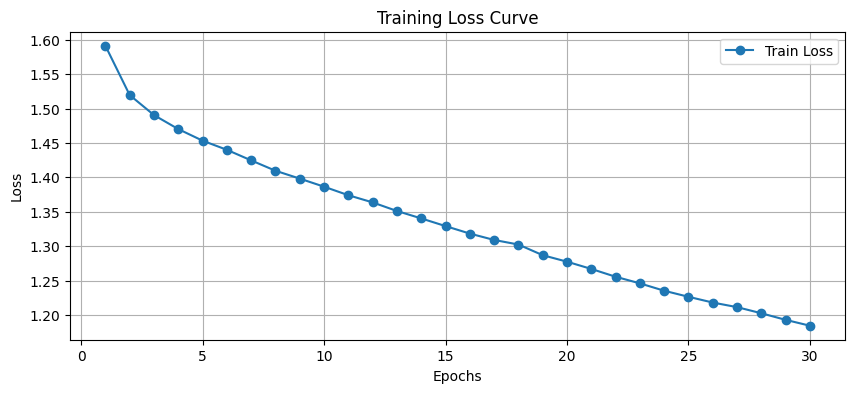

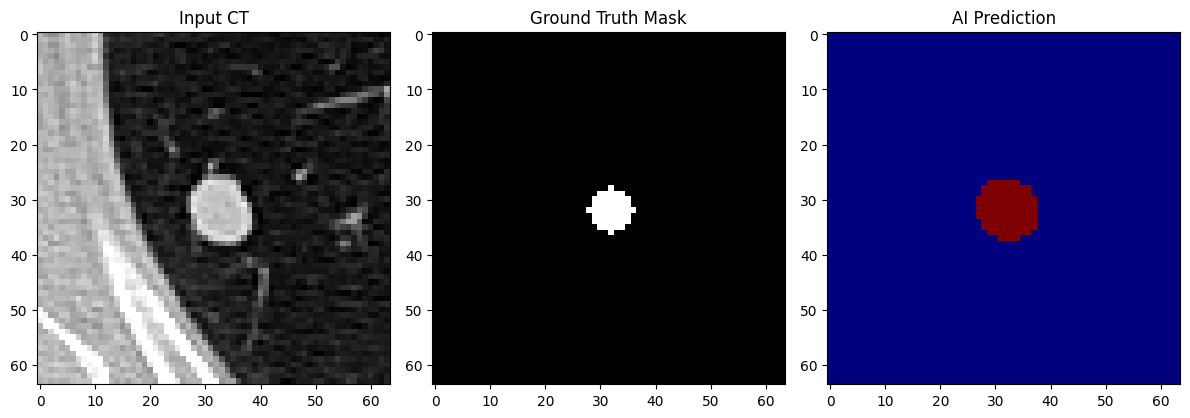

In [7]:
# ==============================================================================
# 6. EVALUATION, VISUALIZATION & AUTO-DOWNLOAD
# ==============================================================================
from google.colab import files # Thư viện để ép trình duyệt tự động tải file

print("\n--- CALCULATING METRICS ---")
model.eval()
dices, ious = [], []

with torch.no_grad():
    for patches, masks in dataloader:
        patches, masks = patches.to(DEVICE), masks.to(DEVICE)
        preds = (model(patches) > 0.5).float()

        for i in range(patches.shape[0]):
            inter = (preds[i] * masks[i]).sum()
            union = preds[i].sum() + masks[i].sum() - inter
            dices.append(((2. * inter) / (preds[i].sum() + masks[i].sum() + 1e-6)).item())
            ious.append((inter / (union + 1e-6)).item())

mean_dice = np.mean(dices)
mean_iou = np.mean(ious)

# Print prominently to the console
print("\n" + "🔥"*15)
print(" FINAL EVALUATION RESULTS (30 Epochs) ")
print("🔥"*15)
print(f"➤ Mean 3D Dice Score: {mean_dice:.4f}")
print(f"➤ Mean 3D IoU Score : {mean_iou:.4f}")
print("="*30 + "\n")

# Plot Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS + 1), losses, marker='o', label='Train Loss')
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig('/content/LOSS_CURVE_3D.png')

# Plot cross-section of the 3D volume
patch, mask, pred = patches[0,0].cpu(), masks[0,0].cpu(), preds[0,0].cpu()
z_mid = patch.shape[0] // 2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(patch[z_mid], cmap='gray'); ax[0].set_title("Input CT")
ax[1].imshow(mask[z_mid], cmap='bone'); ax[1].set_title("Ground Truth Mask")
ax[2].imshow(pred[z_mid], cmap='jet', vmin=0, vmax=1); ax[2].set_title("AI Prediction")

plt.tight_layout()
plt.savefig('/content/RESULT_3D.png')

# Save metrics to text file
with open("/content/evaluation_results_3d.txt", "w") as f:
    f.write(f"Mean 3D Dice Score: {mean_dice:.4f}\n")
    f.write(f"Mean 3D IoU Score : {mean_iou:.4f}\n")

print("Downloading files automatically to your computer...")
try:
    files.download('/content/evaluation_results_3d.txt')
    files.download('/content/LOSS_CURVE_3D.png')
    files.download('/content/RESULT_3D.png')
except Exception as e:
    print("Auto-download failed. You can manually download them from the left sidebar.")